KNN Model
-------------------
Median Salary: 29.73
Accuracy: 0.9166666666666666
Accuracy Percentage: 91.66666666666666 %

Actual vs Predicted Salary Class
   Experience_Years  Actual Salary Class  Predicted Salary Class
0                 3                    0                       0
1                 7                    1                       0
2                16                    1                       1
3                 1                    0                       0
4                 4                    0                       0
5                 0                    0                       0
6                12                    1                       1
7                20                    1                       1
8                17                    1                       1
9                 3                    0                       0


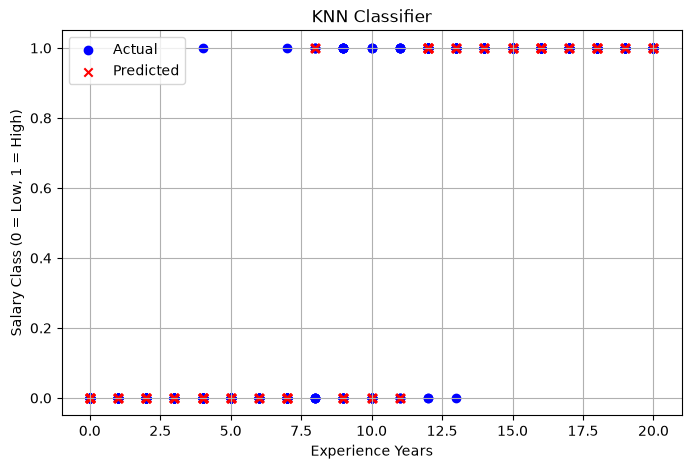

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("preprocessed_data.csv")
median_salary = df["Salary_LPA"].median()

df["Salary_Class"] = (
    df["Salary_LPA"] >= median_salary
).astype(int)
X = df[["Experience_Years"]]
y = df["Salary_Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("KNN Model")
print("-------------------")
print("Median Salary:", median_salary)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

result = pd.DataFrame({
    "Experience_Years": df.loc[
        y_test.index, "Experience_Years"
    ].values,

    "Actual Salary Class": y_test.values,

    "Predicted Salary Class": y_pred
})

print("\nActual vs Predicted Salary Class")
print(result.head(10))
plt.figure(figsize=(8, 5))
plt.scatter(
    df.loc[y_test.index, "Experience_Years"],
    y_test,
    color="blue",
    label="Actual"
)
plt.scatter(
    df.loc[y_test.index, "Experience_Years"],
    y_pred,
    color="red",
    marker="x",
    label="Predicted"
)
plt.title("KNN Classifier")
plt.xlabel("Experience Years")
plt.ylabel("Salary Class (0 = Low, 1 = High)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df.columns

Index(['Employee_Id', 'Age', 'Experience_Years', 'Education_Level',
       'Job_Level', 'Department', 'Performance_Score', 'Weekly_Working_Hours',
       'Salary_LPA'],
      dtype='str')